In [1]:
import numpy as np
import matplotlib.pyplot as plt
from jaxtyping import Float

import muutils.dbg
from muutils.dbg import dbg, dbg_tensor
from muutils.tensor_info import array_summary

from attention_motifs.util import plot_figs, load_activations, get_single_attn_pattern
from attention_motifs.transition_tensor import transition_tensor
from attention_motifs.math import compute_envelope_params, linear_plot

muutils.dbg.DBG_TENSOR_ARRAY_SUMMARY_DEFAULTS["sparkline_logy"] = True

In [2]:
MODEL_NAME: str = "pythia-14m"
MODEL_CFG: dict
PROMPTS: list[dict]
ACTIVATIONS: list[np.lib.npyio.NpzFile]
MODEL_CFG, PROMPTS, ACTIVATIONS = load_activations(MODEL_NAME)

In [3]:
_idxs, _tt, _res = transition_tensor(
	get_single_attn_pattern(0, 0, 0, activations=ACTIVATIONS),
	exact=20,
	approx_l10=4.0,
	approx_pts=20,
)
dbg_tensor(_idxs)
dbg_tensor(_tt)
dbg_tensor(_res)

print()

[ <ipykernel>:7 ] _idxs: μ=899.38 σ=2097.03 x̃=19.50 R=[0.00,10000.00] ℙ=|█▂▁▁ ▁▁| shape=40 dtype=int64
[ <ipykernel>:8 ] _tt: μ=0.01 σ=0.10 x̃=0.00 R=[0.00,1.00] ℙ=|█▃▃▃▃▃▄| shape=(40,82,82) dtype=float32
[ <ipykernel>:9 ] _res: μ=0.09 σ=0.26 x̃=0.01 R=[0.00,1.41] ℙ=|█▄▂▂▃▃▄| shape=(40,82) dtype=float32


In [ ]:
def fig(
	A: np.ndarray,
	axs: list[plt.Axes],
	p_idx: int,
	lyr: int,
	head: int,
	p_threshold: float = 0.95,
):
	# ax_raw, ax_log10, ax_tt, ax_tt_time, ax_tt_dist = axs
	ax_raw, ax_log10, ax_tt, ax_tt_time, ax_tt_dist, ax_vec = axs
	n_ctx: int = A.shape[0]
	#
	ax_raw.set_title("raw attention")
	ax_raw.matshow(A)
	ax_log10.matshow(np.log10(A))

	# compute transition_tensor
	idxs, tt, res = transition_tensor(A, exact=100, approx_l10=7.0, approx_pts=100)

	#
	ax_tt.set_title("transition tensor")
	# ax_log10.matshow(np.log10(1 - tt[:, :, 0].T + 1e-8), aspect=tt.shape[0] / tt.shape[1])
	# use the +1 log
	ax_tt.matshow(np.log1p(1 - tt[:, :, 0].T), aspect=(tt.shape[0] / tt.shape[1]))
	ax_tt.set_xticks(range(len(idxs)))
	ax_tt.set_xticklabels(idxs)
	ax_tt.tick_params(axis="x", rotation=90)

	#
	# ax_tt.set_title("residuals tensor")
	# # aspect should be such that the image is square, although the matrix is not
	# ax_tt.matshow(res.T, aspect=(res.shape[0] / res.shape[1]))
	# ax_tt.set_xticks(range(len(idxs)))
	# ax_tt.set_xticklabels(idxs)
	# ax_tt.tick_params(axis="x", rotation=90)

	#
	# ax_ttres.set_title("residuals tensor (log10)")
	# ax_ttres.matshow(np.log10(res.T + 1e-8), aspect=(res.shape[0] / res.shape[1]))
	# ax_ttres.set_xticks(range(len(idxs)))
	# ax_ttres.set_xticklabels(idxs)
	# ax_ttres.tick_params(axis="x", rotation=90)

	ax_tt_time.set_title(f"time to transition probability > {p_threshold}")
	indices_raw = np.apply_along_axis(
		lambda row: np.searchsorted(row, p_threshold, side="right"),
		axis=0,
		arr=tt[:, :, 0],
	)
	ax_tt.plot(indices_raw, np.arange(indices_raw.shape[0]), "r.")
	idxs_with_inf = np.concatenate((idxs, [1e10]))
	indices_adjusted = np.array(idxs_with_inf[indices_raw], dtype=float)
	# if last element, set to inf
	# indices_adjusted[indices_raw == len(idxs)] = 1e10
	indices_adjusted_l10 = np.log10(indices_adjusted[1:])
	ax_tt_time.plot(indices_adjusted_l10, "ro")
	ax_tt_time.set_xlabel("token idx")
	ax_tt_time.set_ylabel("log10(iters to transition)")
	dbg_tensor(indices_adjusted)
	dbg_tensor(indices_adjusted_l10)
	idxs_x = np.arange(len(indices_adjusted_l10))
	for envtype in ("lower", "upper", "bestfit"):
		env_lower = compute_envelope_params(
			x=idxs_x,
			y=indices_adjusted_l10,
			envelope_type=envtype,
		)
		ax_tt_time.plot(
			idxs_x,
			linear_plot(idxs_x, env_lower[0], env_lower[1]),
			label=f"{envtype}, $R^2={env_lower[2]:.3f}$",
		)
	ax_tt_time.legend()

	indices_adjusted_diff = np.diff(indices_adjusted)
	ax_tt_dist.set_title(
		f"dist of transition times diff\n${array_summary(indices_adjusted_diff, fmt='latex', dtype=False)}$"
	)
	ax_tt_dist.hist(indices_adjusted_diff, bins=10)
	ax_tt_dist.set_ylabel("count")

	#
	# axs[5].set_title("transition time fft")
	# tt_time_fft = np.fft.fft(idxs_with_inf)
	# # print(tt_time_fft)
	# axs[5].plot(np.abs(tt_time_fft), "o-", label="abs")
	# # axs[5].plot(np.angle(tt_time_fft), label="angle")
	# # axs[5].plot(tt_time_fft.real, label="real")
	# # axs[5].plot(tt_time_fft.imag, label="imaginary")
	# axs[5].set_yscale("log")
	# axs[5].legend()

	A_diag = A.diagonal()
	A_col0 = A[:, 0]
	# linear regression on these
	# ax_vec.plot(A_diag, "o", label="diag")
	# ax_vec.plot(A[:,0], "o", label="col0")
	# fit these to a beta
	# ax_vec.hist(A_diag, alpha=0.5, label="diag")
	# ax_vec.hist(A[:,0], alpha=0.5, label="col0")
	# variance of these
	# ax_vec.plot(np.diff(A_diag), "o", label="diag")
	# ax_vec.plot(np.diff(A[:,0]), "o", label="col0")
	# print(np.correlate(A_diag, A_diag, mode="full"))
	ax_vec.plot(np.correlate(A_diag, A_diag, mode="some"), "o", label="diag")
	ax_vec.plot(np.correlate(A_col0, A_col0, mode="some"), "o", label="col0")

	ax_vec.legend()

plot_figs(
	n_figures=3,
	model_cfg=MODEL_CFG,
	prompt_dicts=PROMPTS,
	activations=ACTIVATIONS,
	figure_func=fig,
	prompts=[0, 1, 2],
	layers=None,
	heads=[0],
)

plt.show()

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 0, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.03 σ=0.06 x̃=0.01 R=[0.00,1.00] ℙ=|█▄▃▂▂▁▁| shape=6724 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=1.72 x̃=0.42 R=[0.07,9.07] ℙ=|█▂▁▁  ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.37397347091495126, 2.5451593429872252, 0.013495740484920518, 1.2862907783056001)


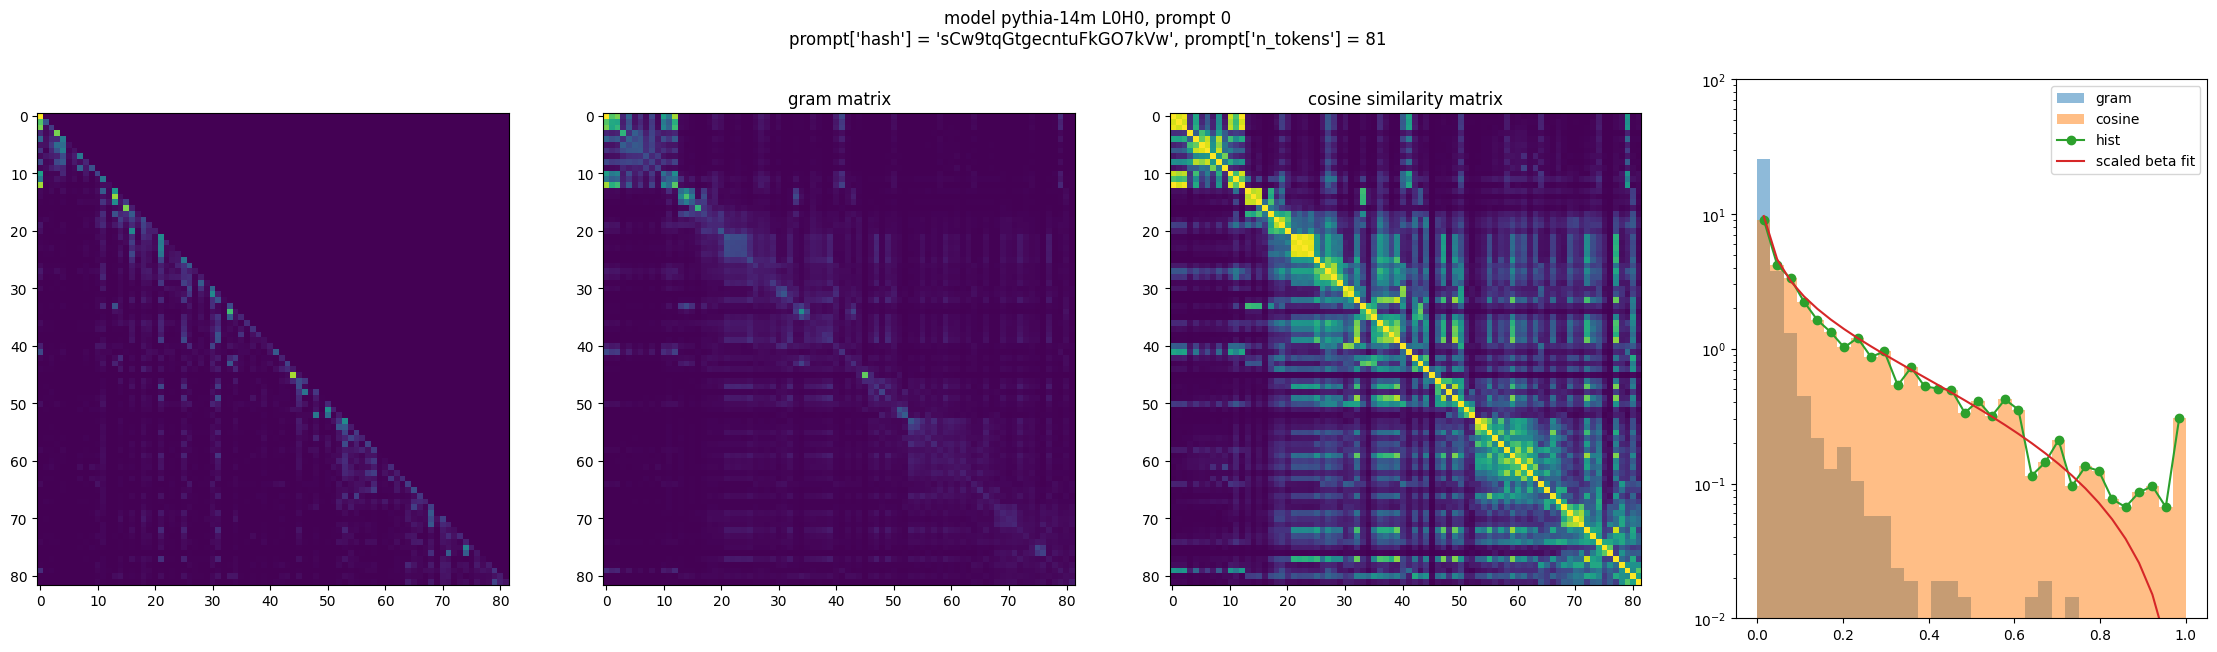

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 1, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.01 σ=0.08 x̃=0.00 R=[0.00,1.00] ℙ=|█▃▃▃▂▂▂| shape=6724 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=5.24 x̃=0.04 R=[0.00,30.19] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.06714760002916073, 2.9430863644540874, -0.015955395562099926, 1.948131122076715)


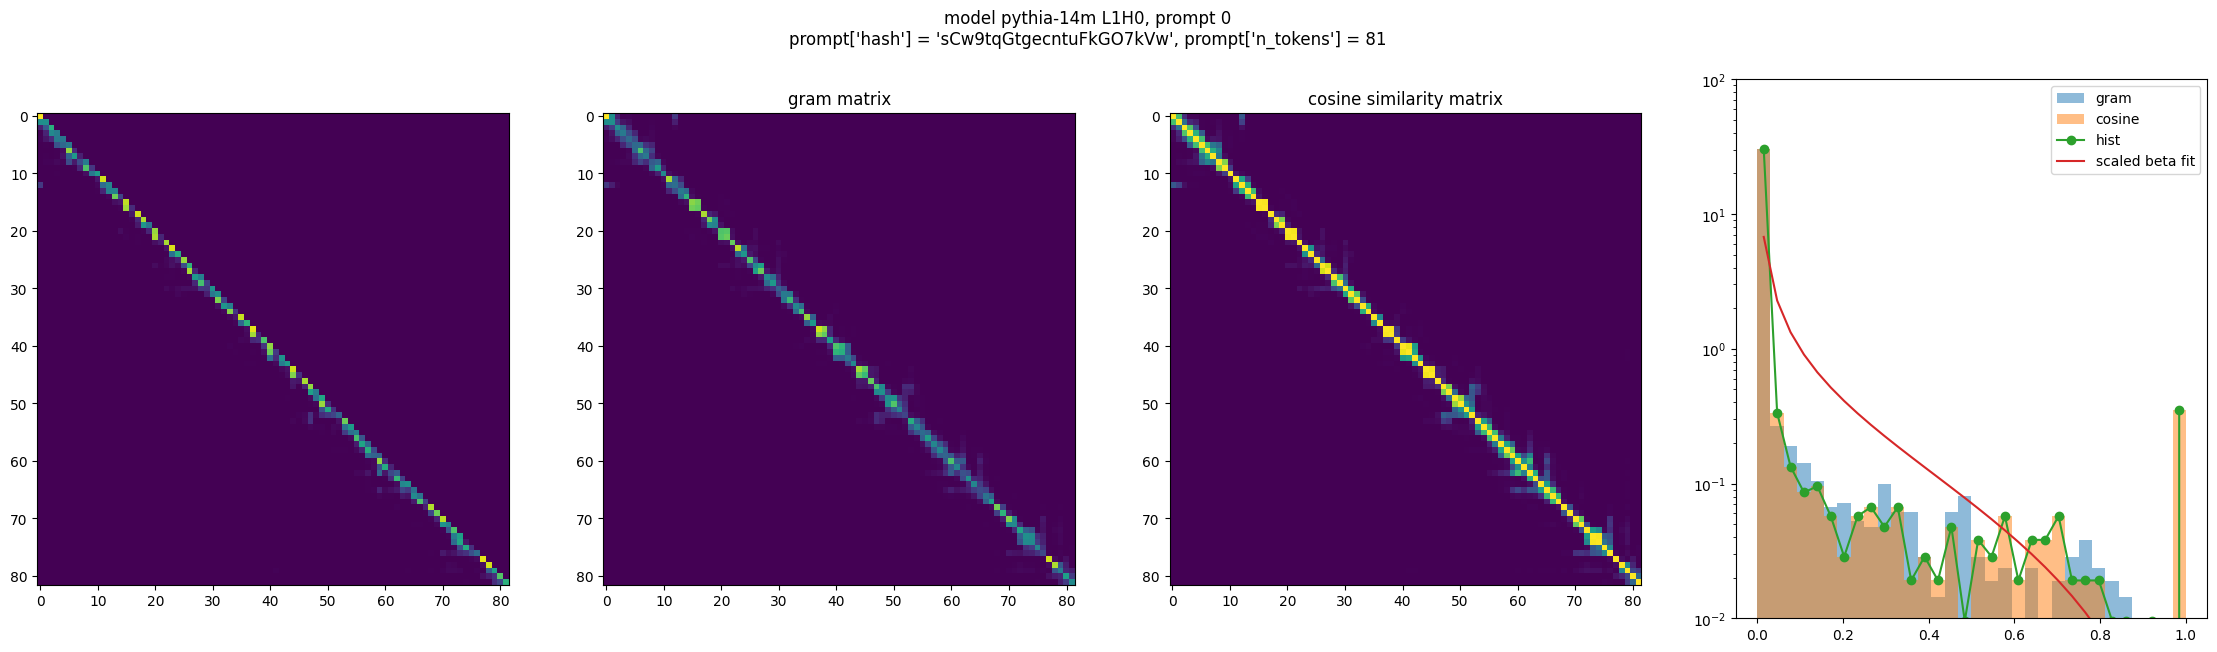

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 2, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.05 σ=0.06 x̃=0.03 R=[0.00,1.00] ℙ=|█▅▃▁▁  | shape=6724 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=0.71 x̃=0.66 R=[0.22,2.25] ℙ=|█▅ ▄▂▄▅| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (1.5221460505235669, 5.937836166783754, -0.018966600709869122, 1.7180482466540754)


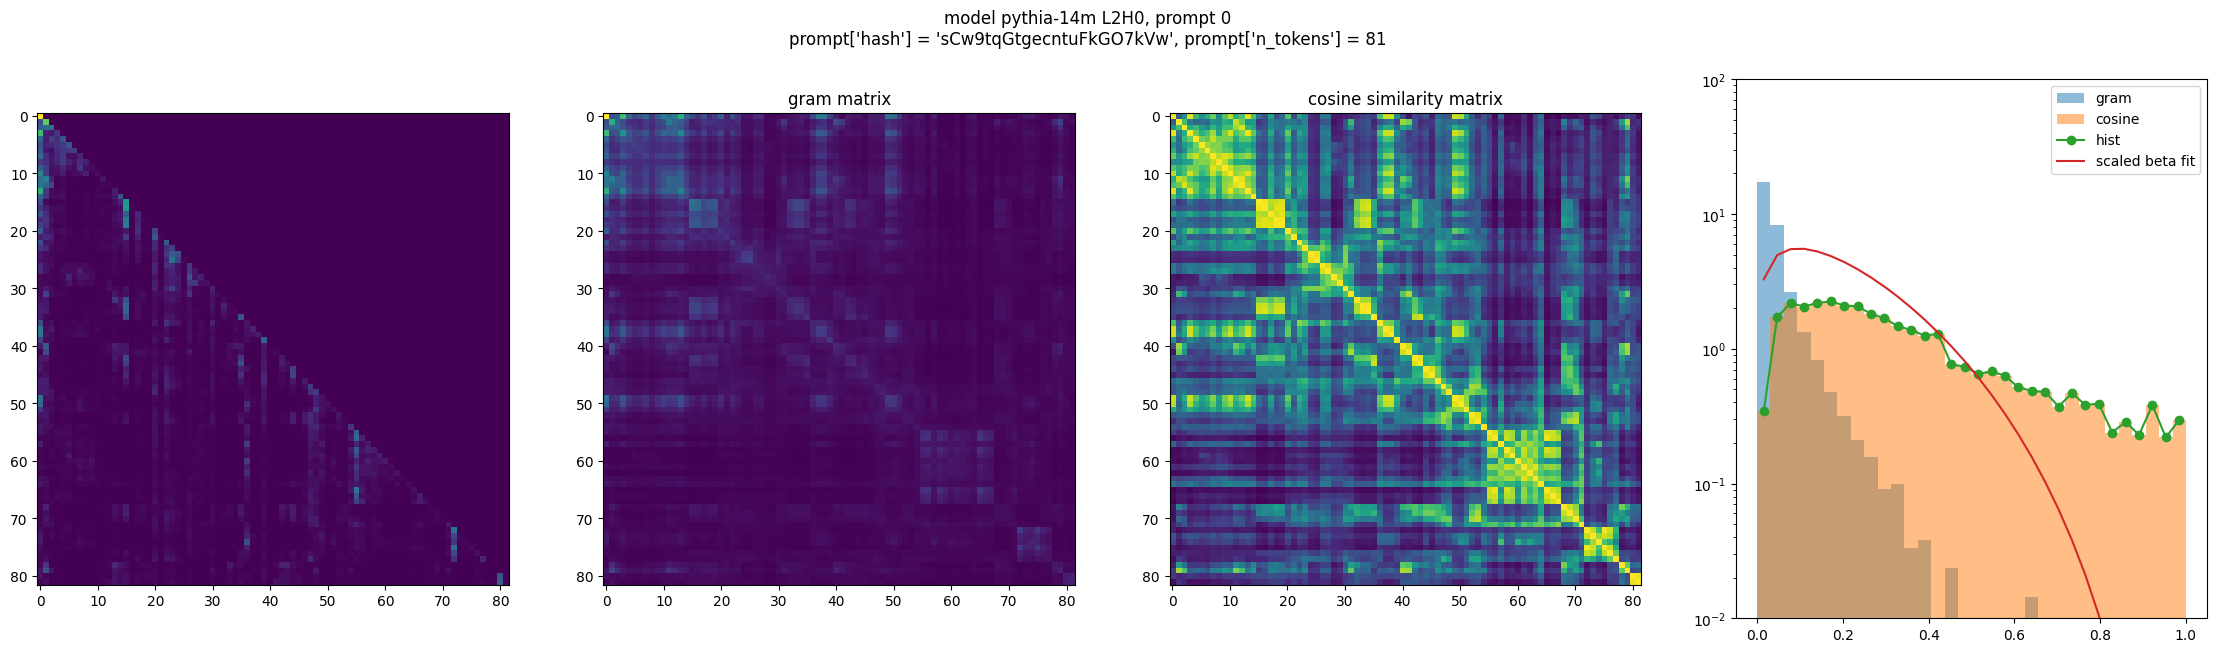

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 3, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.24 σ=0.21 x̃=0.18 R=[0.00,1.00] ℙ=|█▇▆▆▅▅▄| shape=6724 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=0.52 x̃=0.77 R=[0.37,2.70] ℙ=|█▆▅▅▄ ▂| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.4884815502068214, 0.5666398575133178, 0.03196952193956515, 0.9757343674746939)


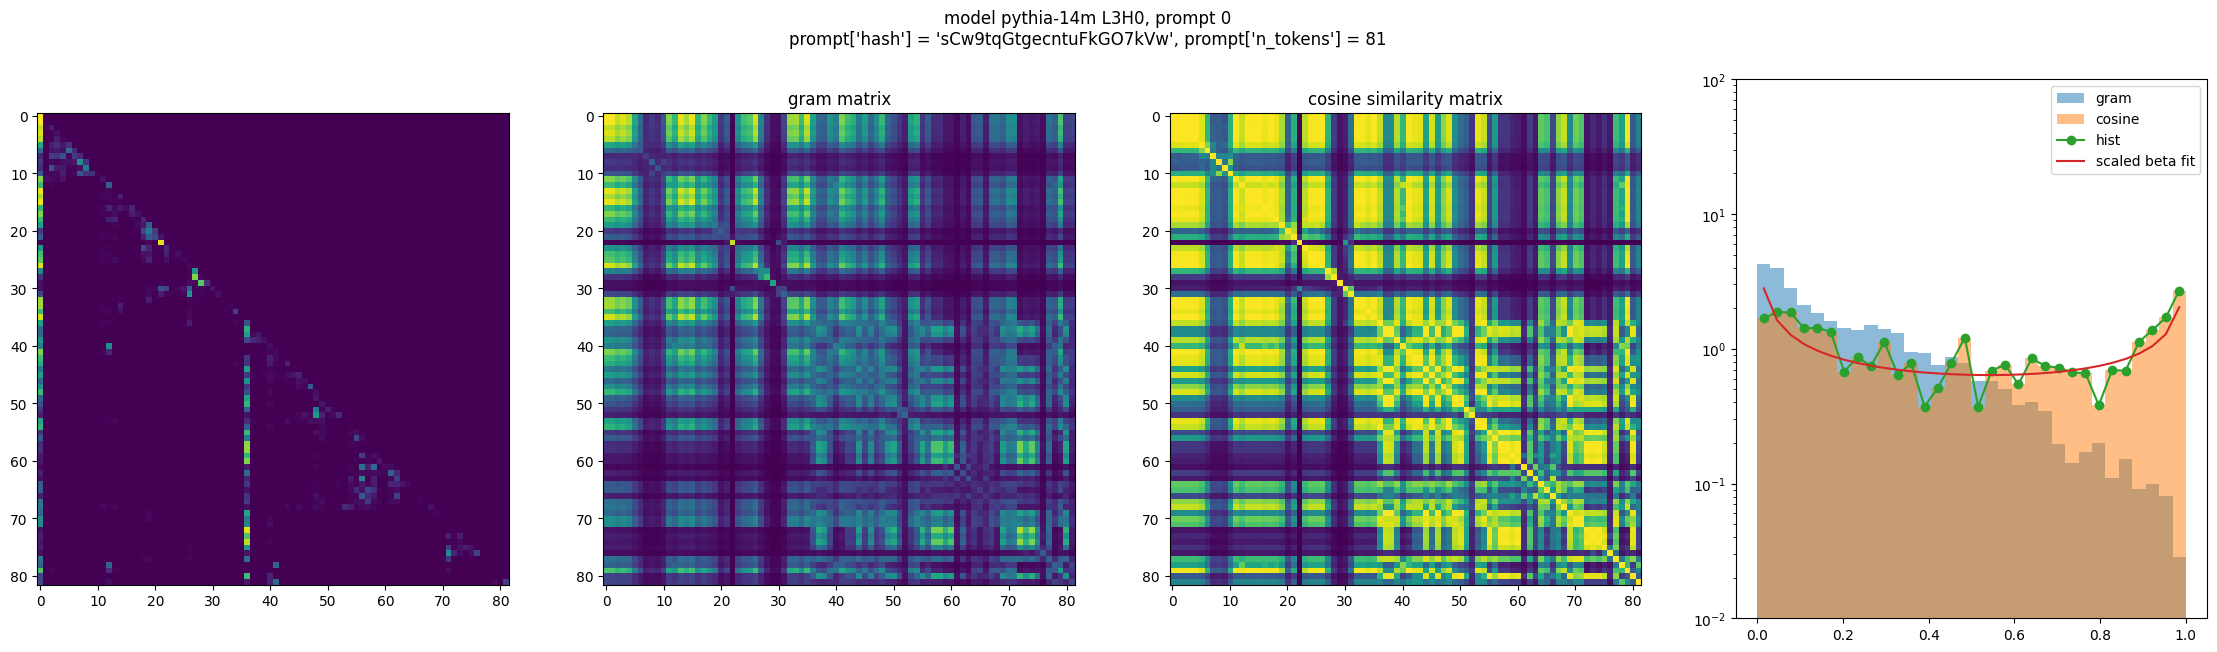

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 4, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.07 σ=0.18 x̃=0.00 R=[0.00,1.00] ℙ=|█▅▄▄▃▄▄| shape=6724 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=3.95 x̃=0.17 R=[0.04,22.94] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.07682795642244547, 0.6581380022346254, -0.0023081812688054357, 1.1111791293428137)


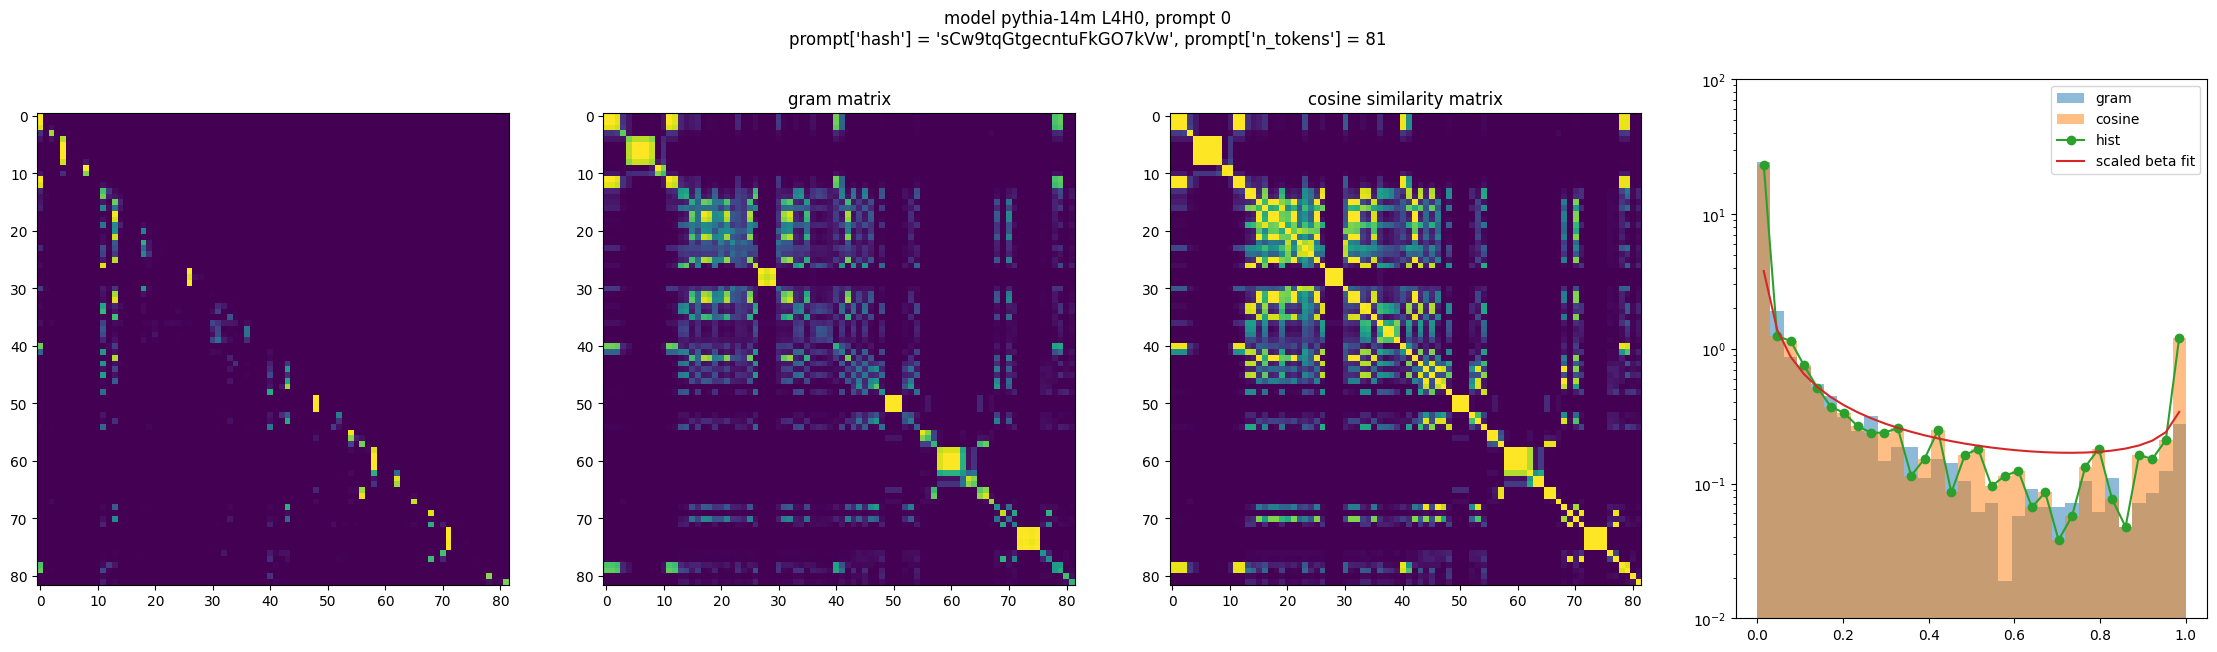

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 5, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.15 σ=0.33 x̃=0.00 R=[0.00,1.00] ℙ=|█▃▄▄▄▄▆| shape=6724 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=4.37 x̃=0.04 R=[0.00,25.10] ℙ=|█▁    ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.029407052342141197, 0.13405287809851107, -0.006616265620000302, 1.012435676231169)


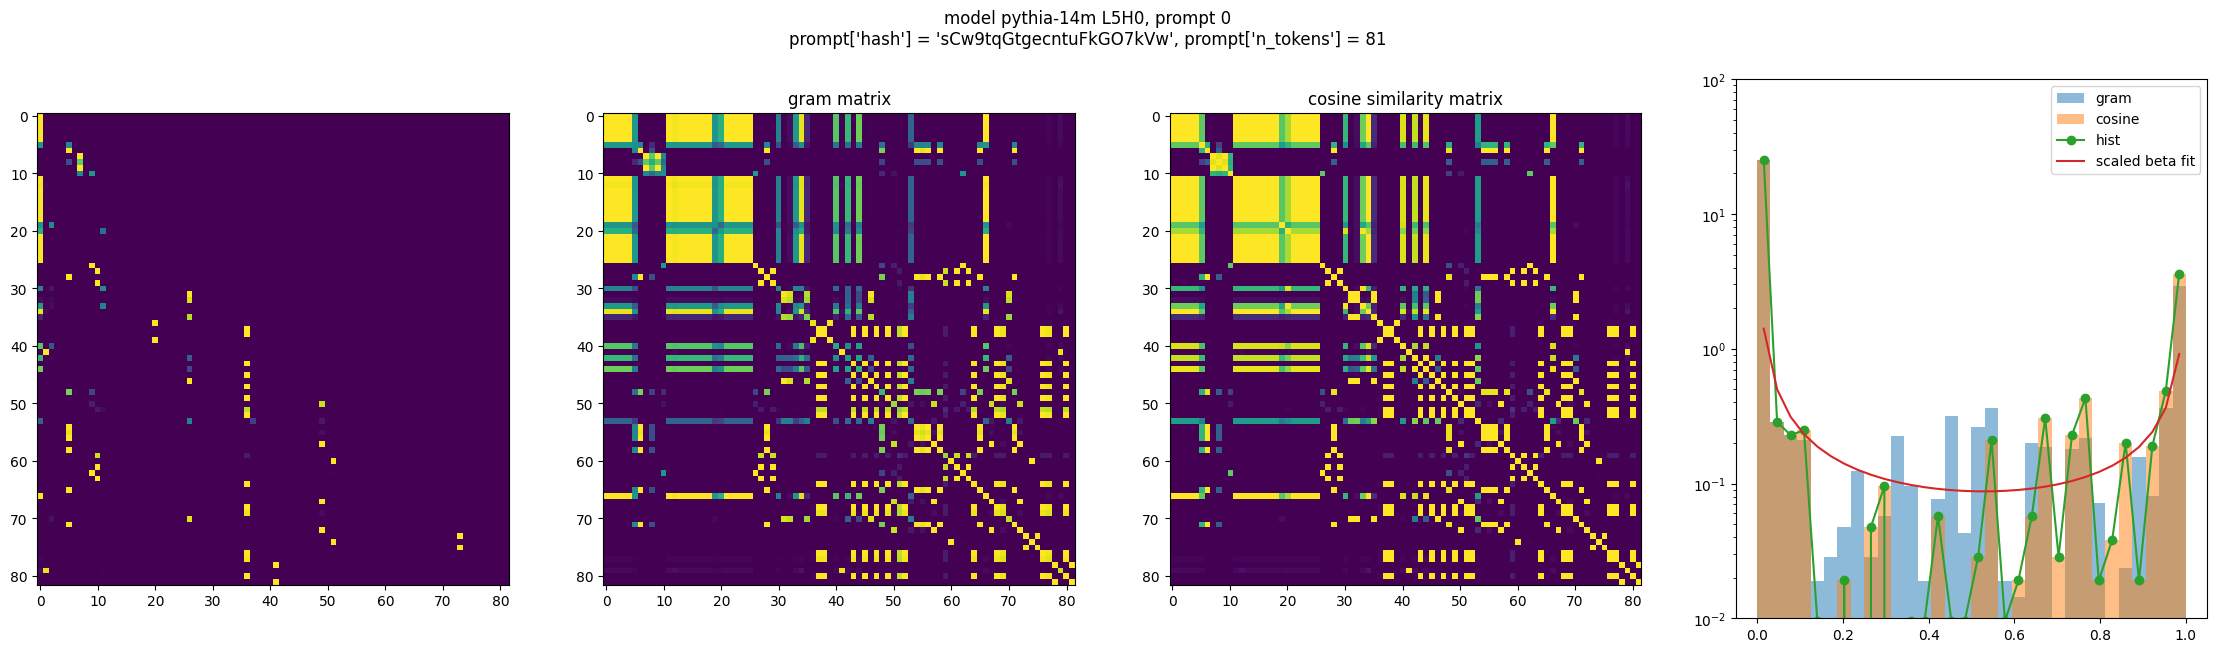

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 0, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.08 σ=0.13 x̃=0.03 R=[0.00,1.00] ℙ=|█▅▄▄▃▂▁| shape=2916 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=1.37 x̃=0.40 R=[0.09,6.60] ℙ=|█▄▁▁▁ ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.21050068119224868, 0.891168560834037, 0.041148508332037405, 1.0836837209867354)


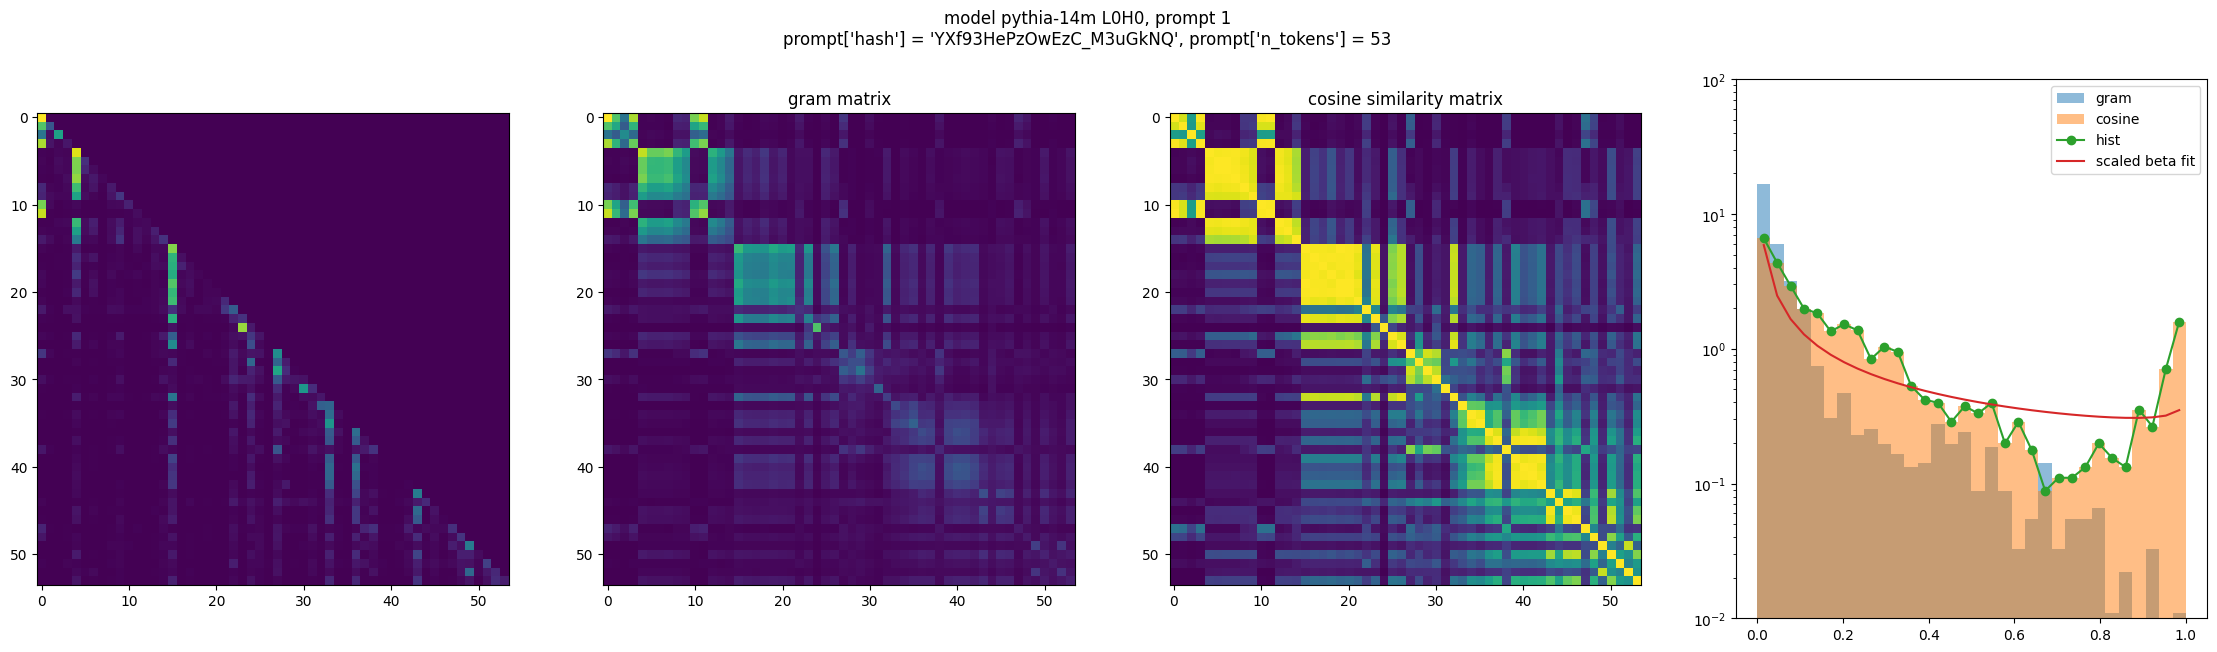

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 1, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.02 σ=0.11 x̃=0.00 R=[0.00,1.00] ℙ=|█▃▂▃▃▁▂| shape=2916 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=5.24 x̃=0.02 R=[0.00,30.19] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.006792081542108596, 0.20036634648944374, 0.0013689460427594989, 1.0227399012876148)


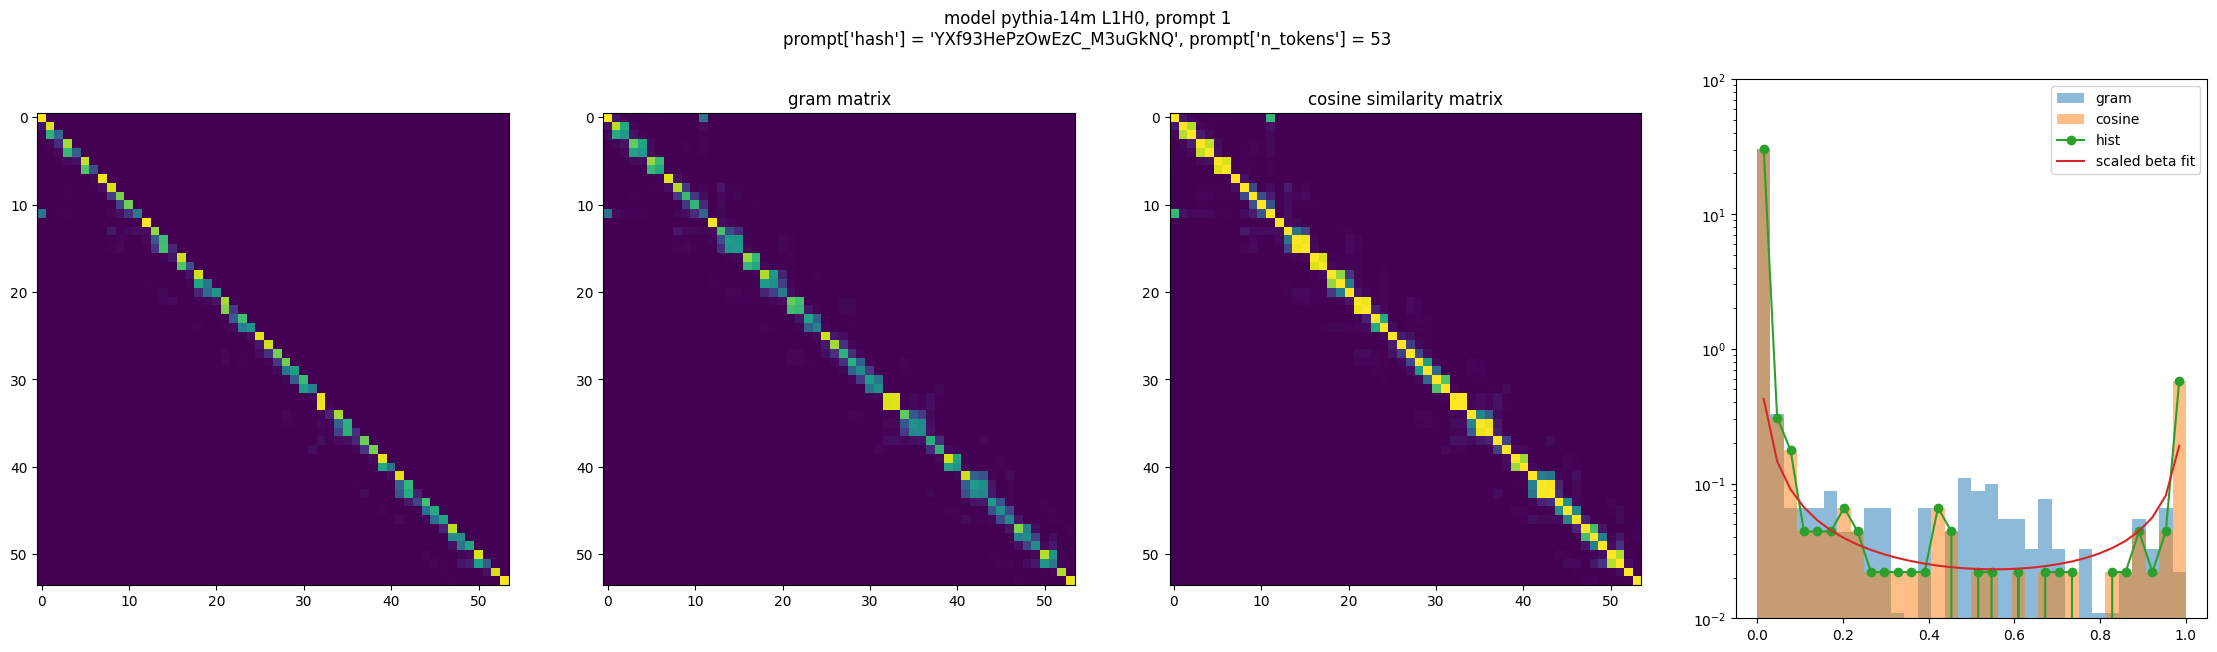

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 2, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.08 σ=0.08 x̃=0.05 R=[0.01,1.00] ℙ=|█▄▄▃▂▁ | shape=2916 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=0.71 x̃=0.89 R=[0.00,2.22] ℙ=|██▇▆▆▂█| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (3.819051880885678, 9.539364371634594, 0.03001629261552572, 1.6617314467740665)


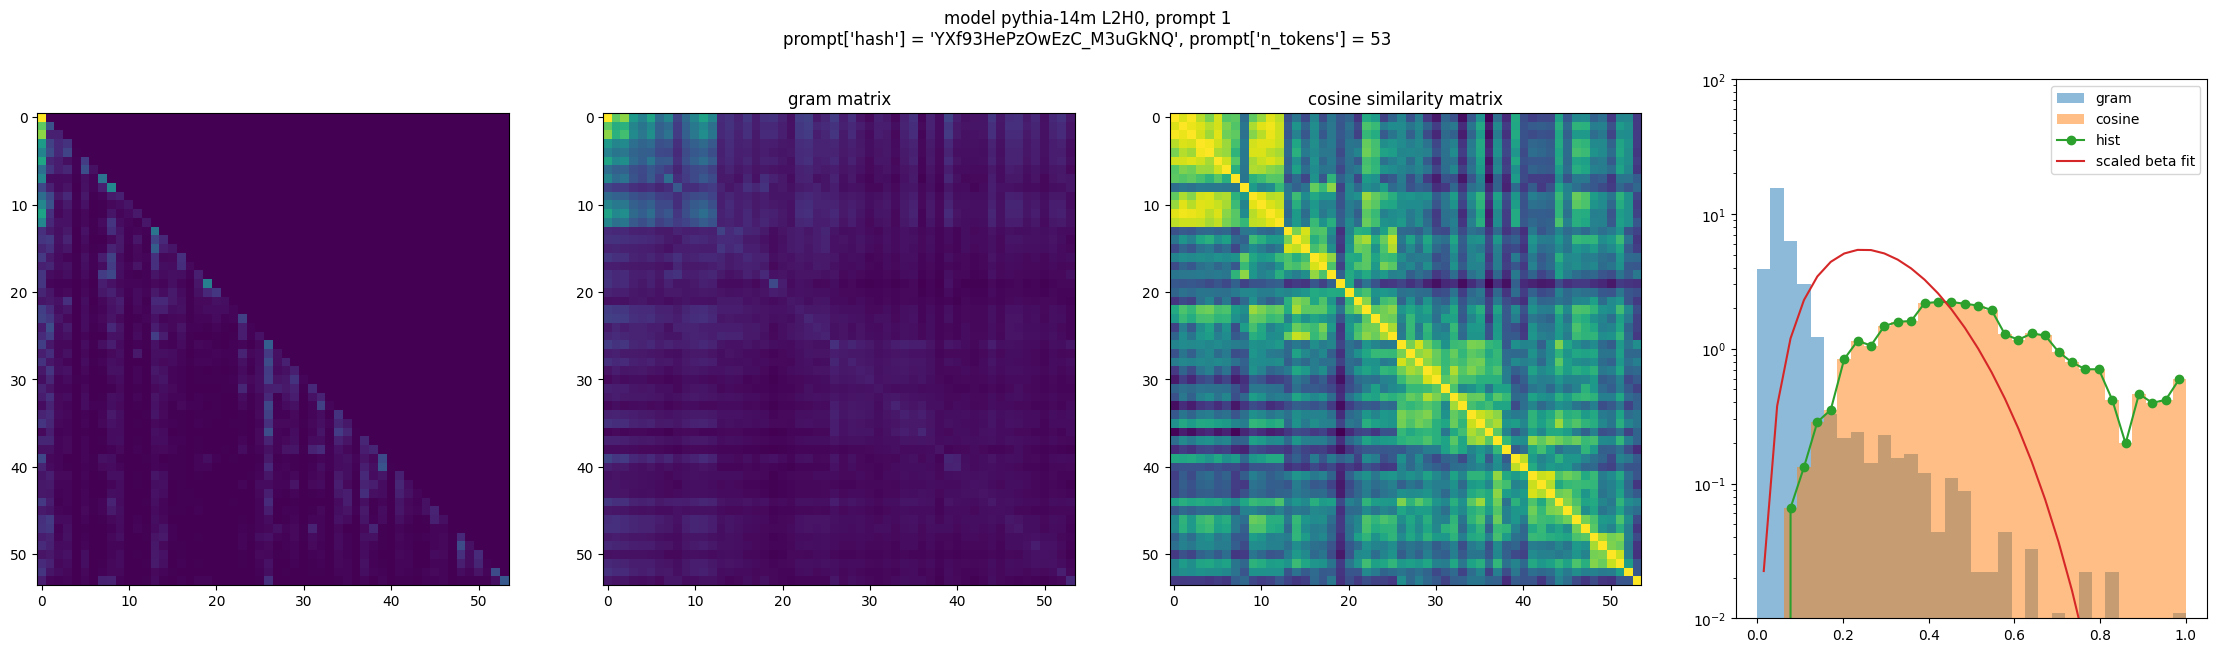

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 3, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.40 σ=0.24 x̃=0.36 R=[0.01,1.00] ℙ=|▇▇█▇▇▆▆| shape=2916 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=1.36 x̃=0.70 R=[0.00,7.39] ℙ=|█▆▁   ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (1.8927546319500839, 0.43926931323196877, -0.20620900311941948, 1.1791113734547016)


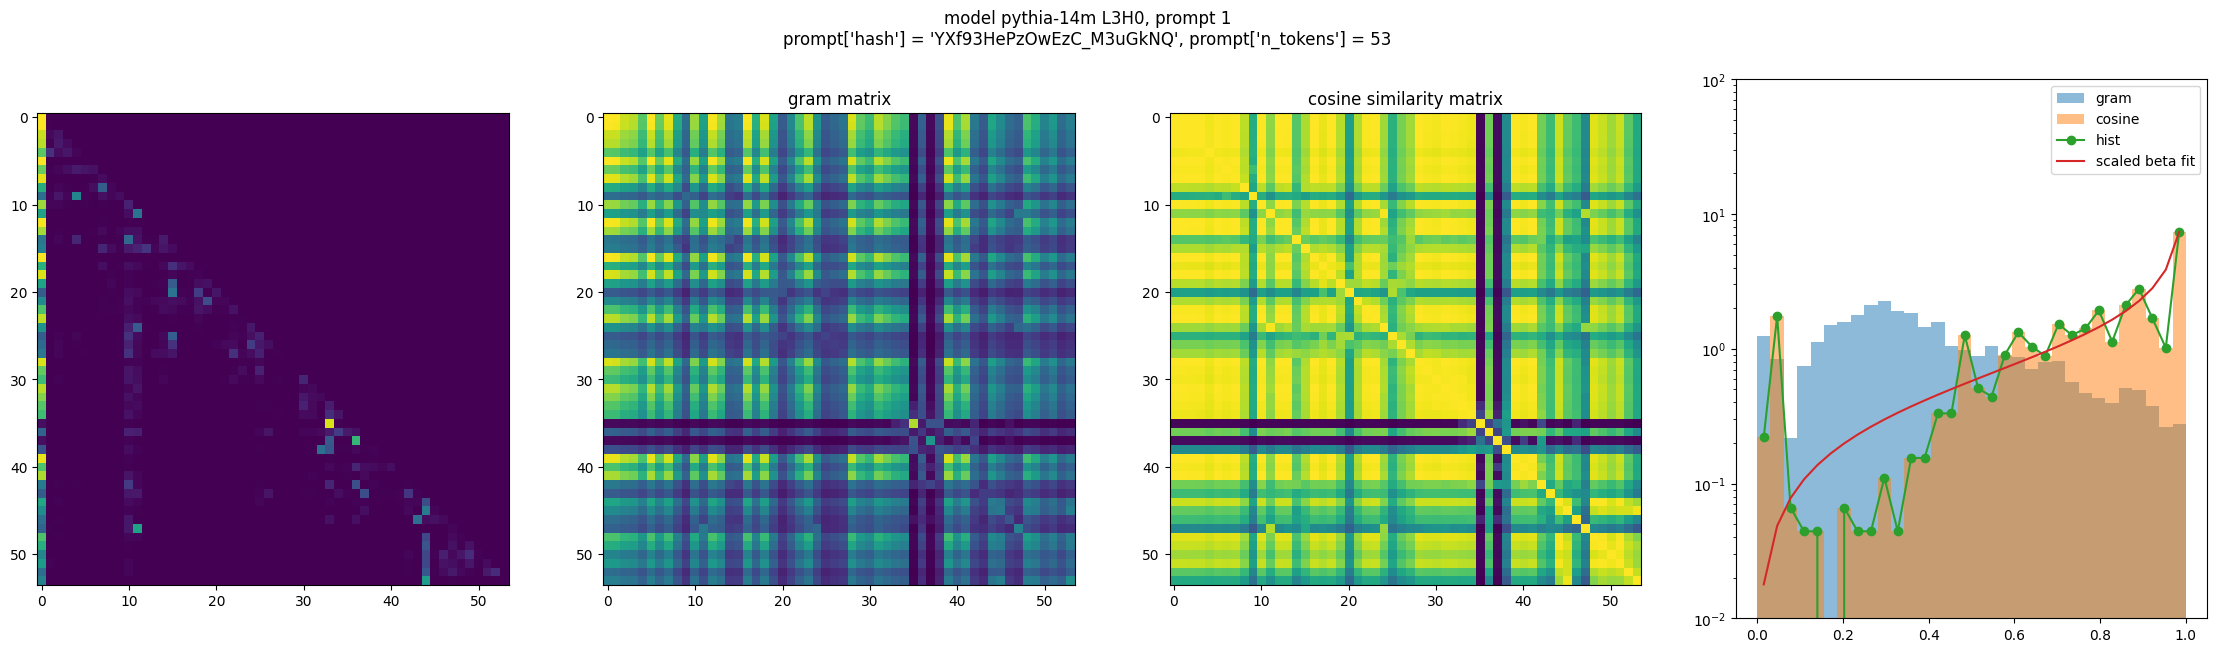

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 4, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.28 σ=0.31 x̃=0.17 R=[0.00,1.00] ℙ=|█▆▆▄▅▅▆| shape=2916 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=1.32 x̃=0.57 R=[0.09,6.64] ℙ=|█▄   ▁▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.38075450754097195, 0.4607843934134566, -0.007588057175665408, 1.0323227016439747)


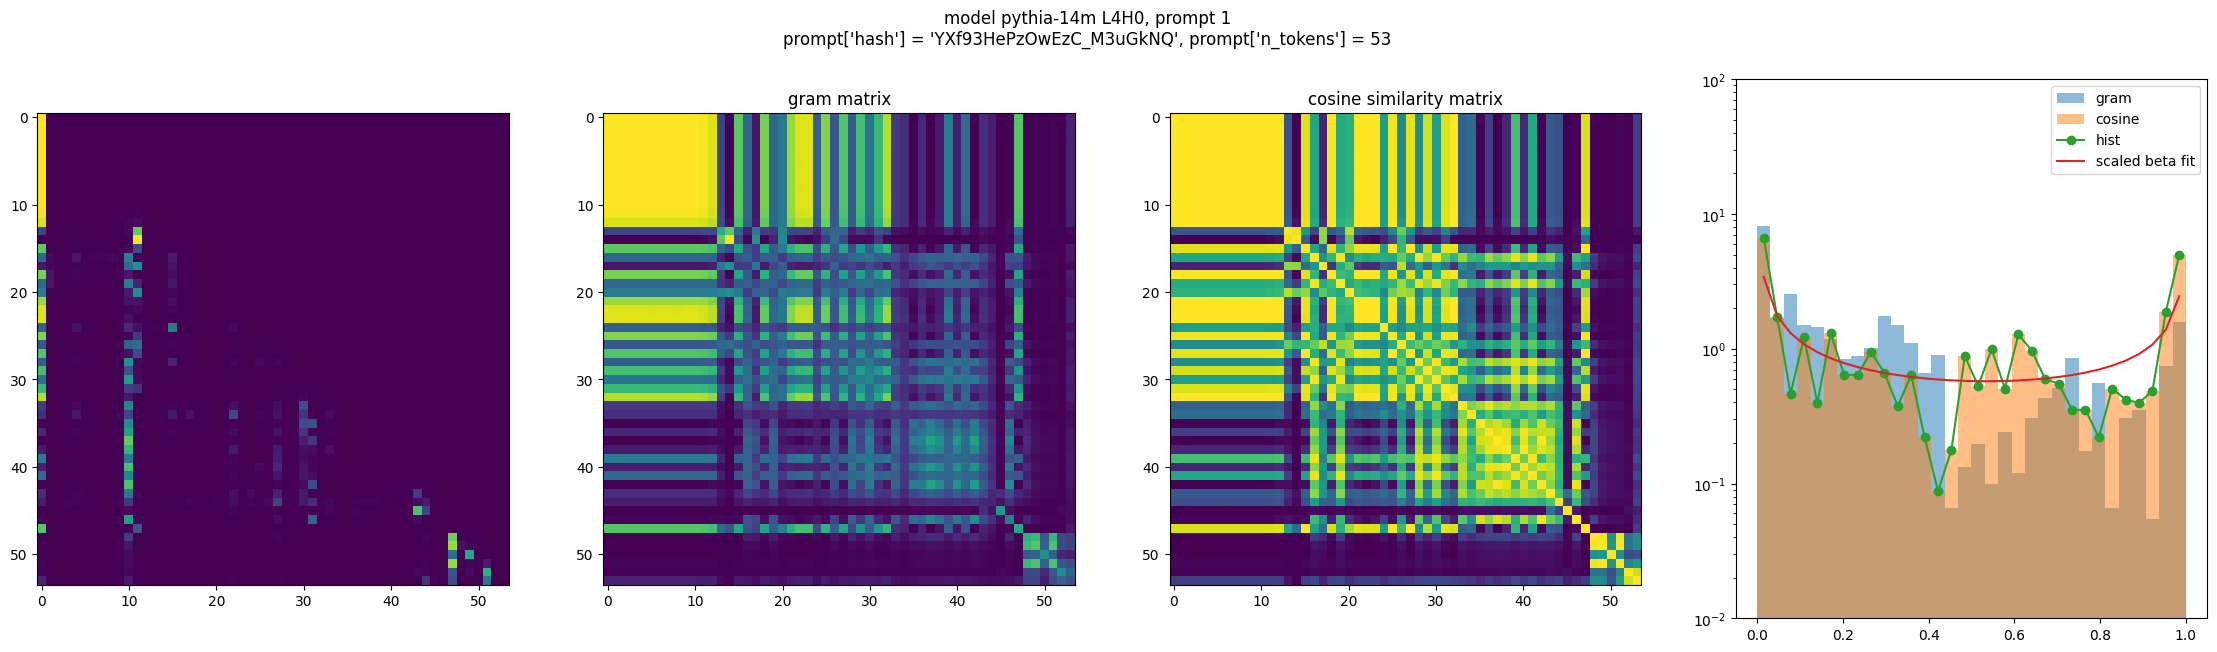

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 5, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.38 σ=0.44 x̃=0.02 R=[0.00,1.00] ℙ=|█▃▆▃▃▅▇| shape=2916 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=3.27 x̃=0.04 R=[0.00,16.32] ℙ=|█   ▁ ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.07304297045128422, 0.10497121022190326, -0.007458161498497789, 1.0157823263479184)


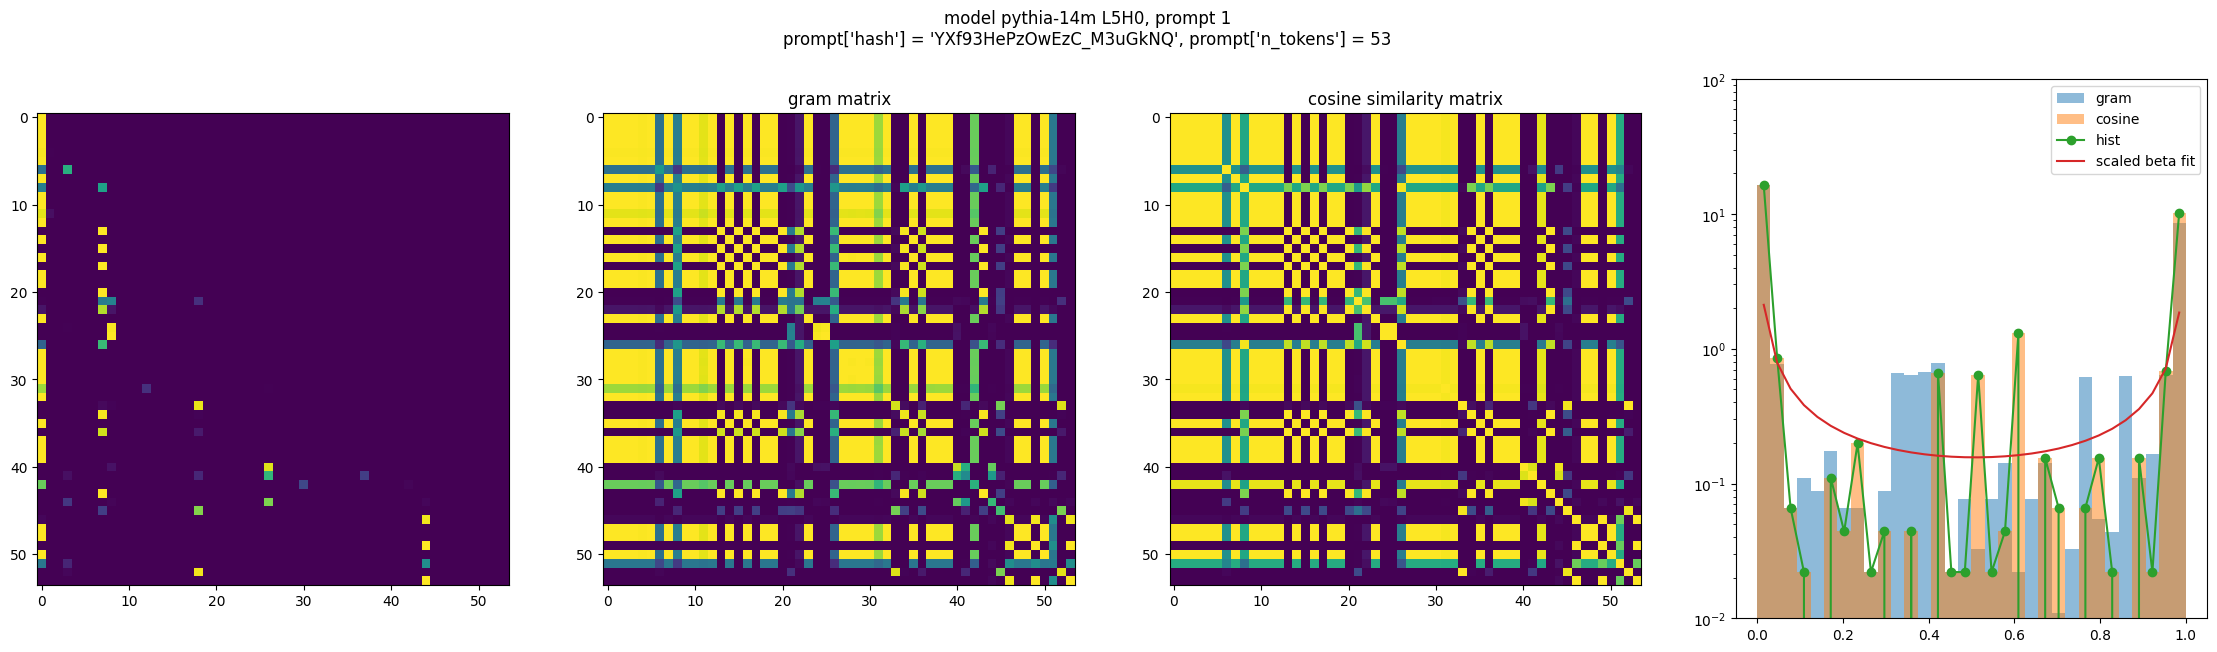

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (2, 0, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.05 σ=0.07 x̃=0.03 R=[0.00,1.00] ℙ=|█▄▃▂▁▁ | shape=3025 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=1.06 x̃=0.50 R=[0.17,4.85] ℙ=|█▃▄ ▂ ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.4601775017758388, 1.895619061741094, 0.028311871391835584, 1.1656158829705474)


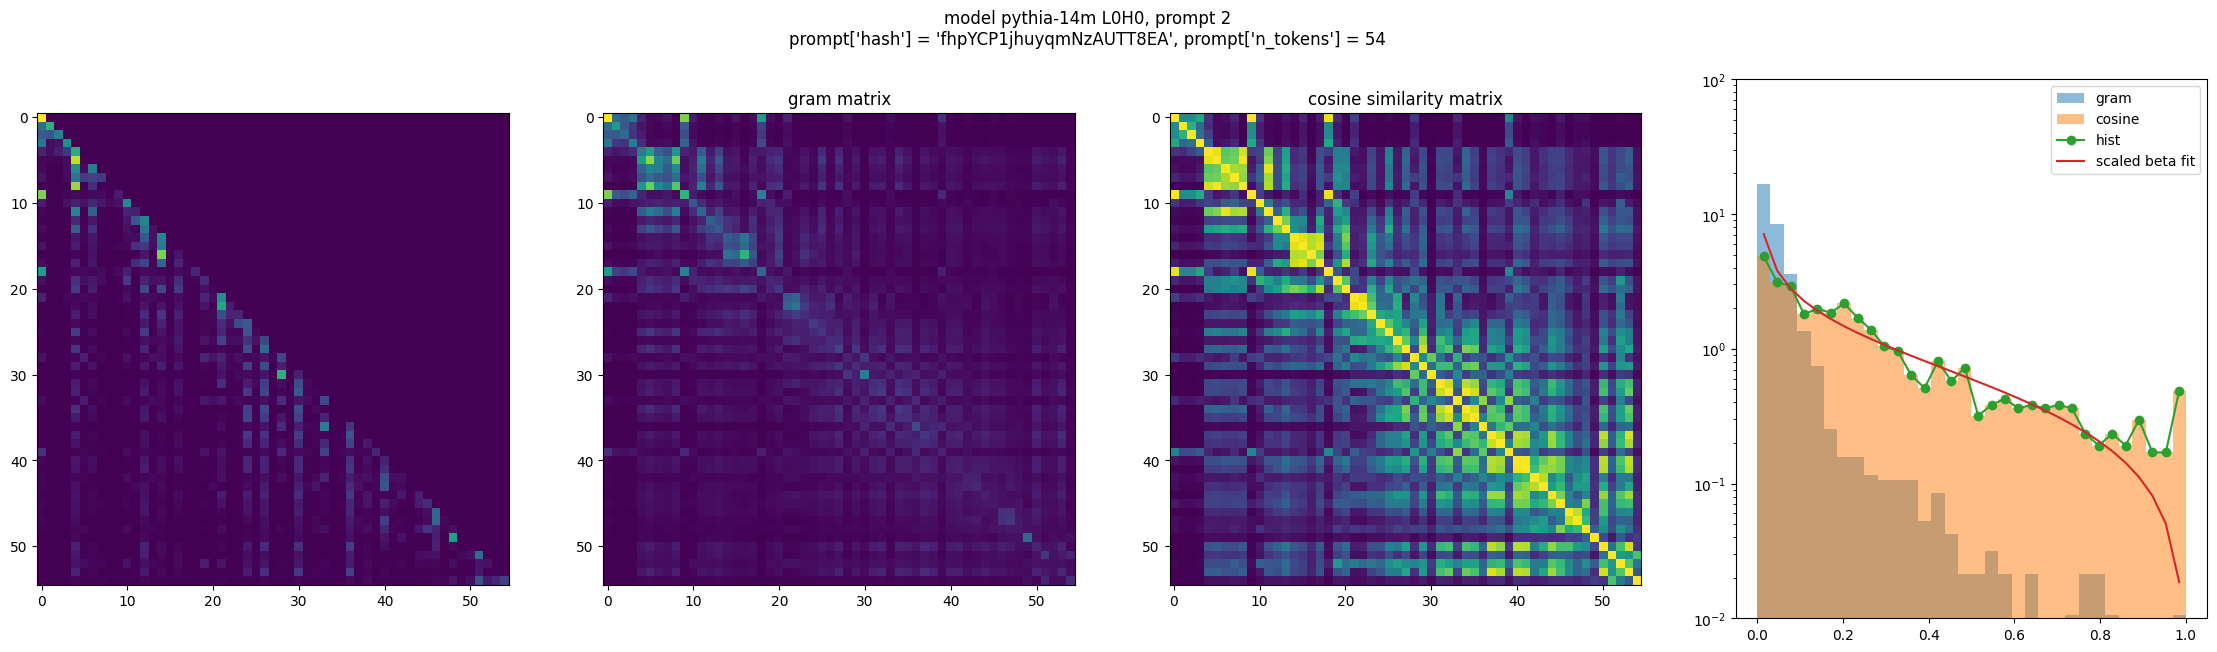

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (2, 1, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.02 σ=0.11 x̃=0.00 R=[0.00,1.00] ℙ=|█▃▂▃▃▂▂| shape=3025 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=5.16 x̃=0.04 R=[0.00,29.74] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.006739701717795485, 0.1912778210291925, 0.00206876536942208, 1.0152139742963886)


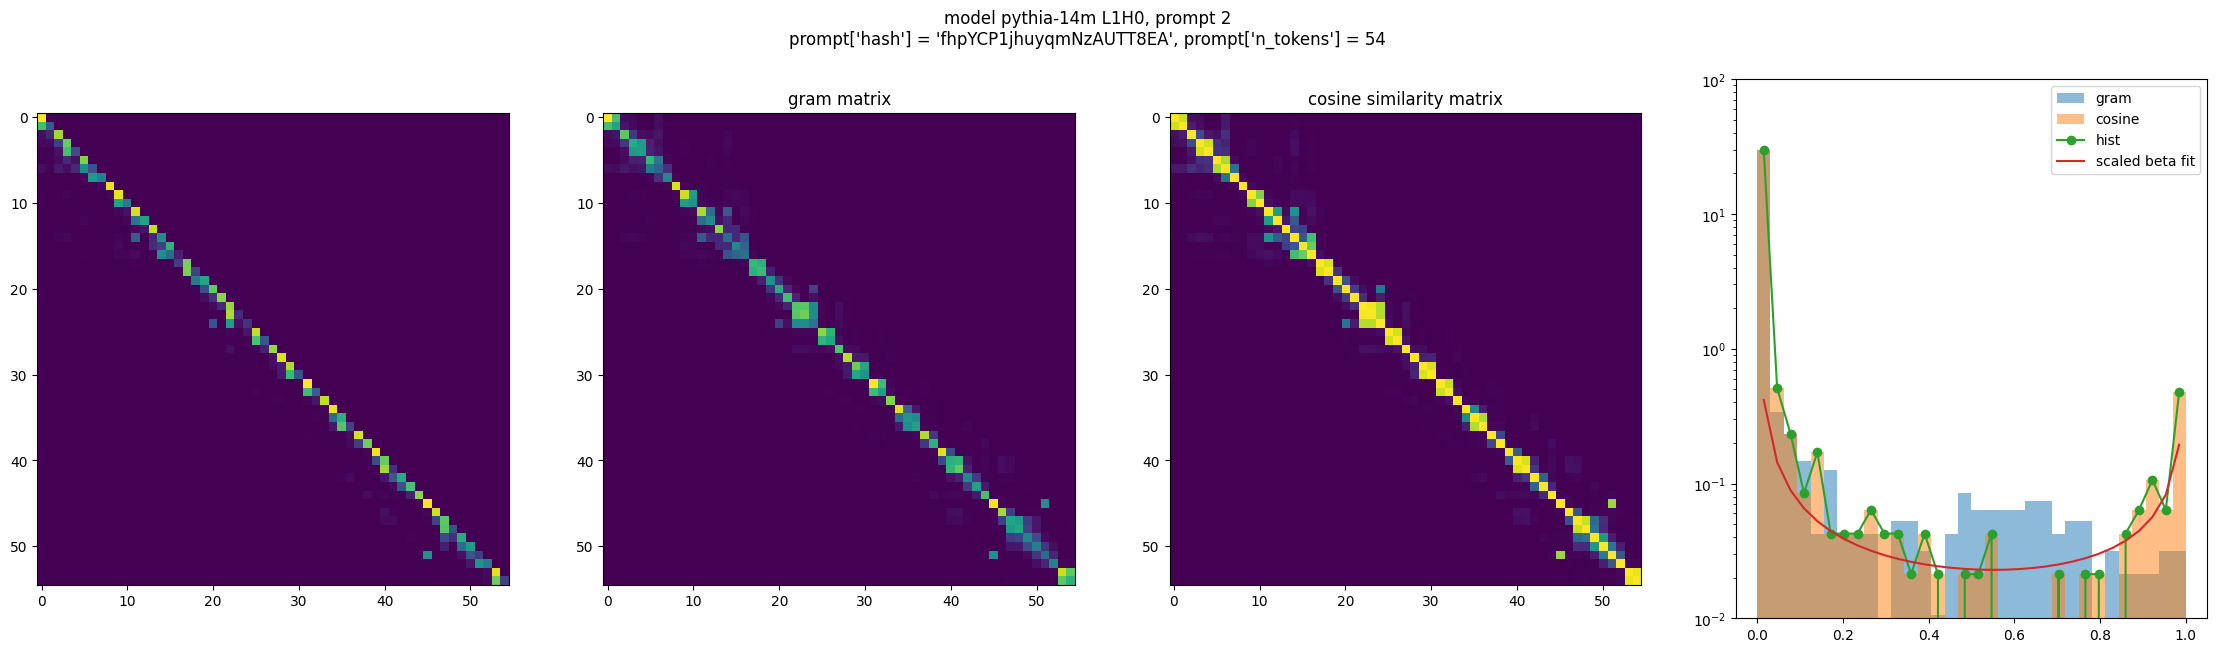

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (2, 2, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.07 σ=0.09 x̃=0.05 R=[0.01,1.00] ℙ=|█▅▃▃▁▂▂| shape=3025 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=0.49 x̃=1.03 R=[0.13,2.02] ℙ=|▅▆▆▅█▂▄| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (1.229853499601537, 2.4328792792805745, 0.014760854101519748, 1.1465710380564182)


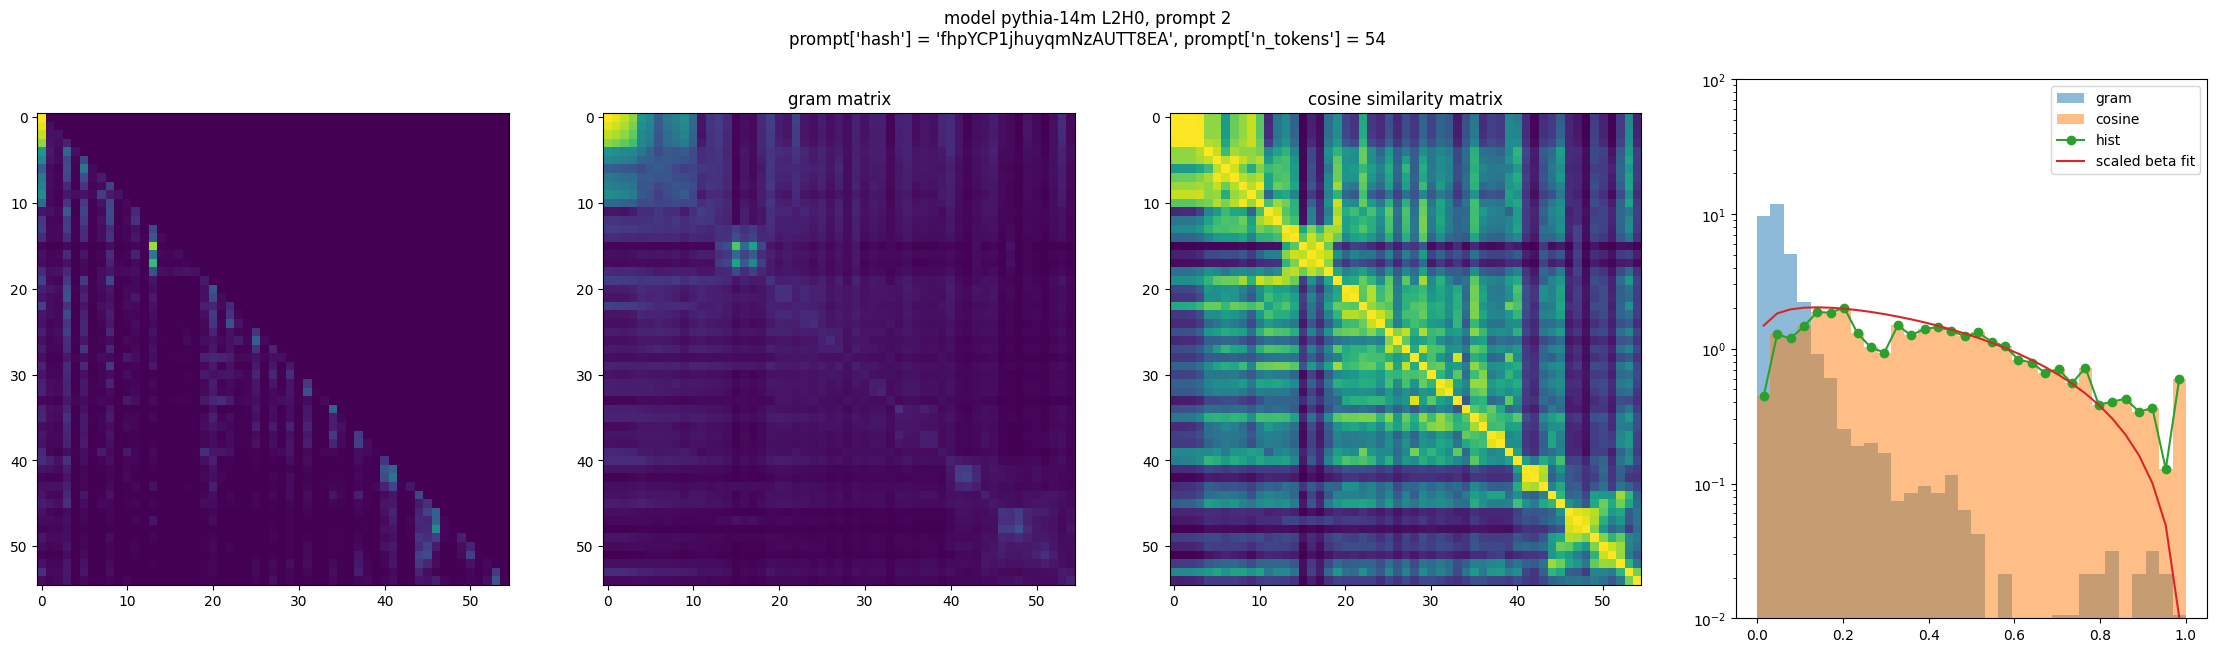

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (2, 3, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.14 σ=0.13 x̃=0.11 R=[0.00,1.00] ℙ=|█▇▅▄▃▂▁| shape=3025 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=0.44 x̃=0.90 R=[0.34,2.62] ℙ=|▅█▆▄  ▂| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.6046823375609667, 0.660559008131784, 0.011512672553423055, 0.9827921695127358)


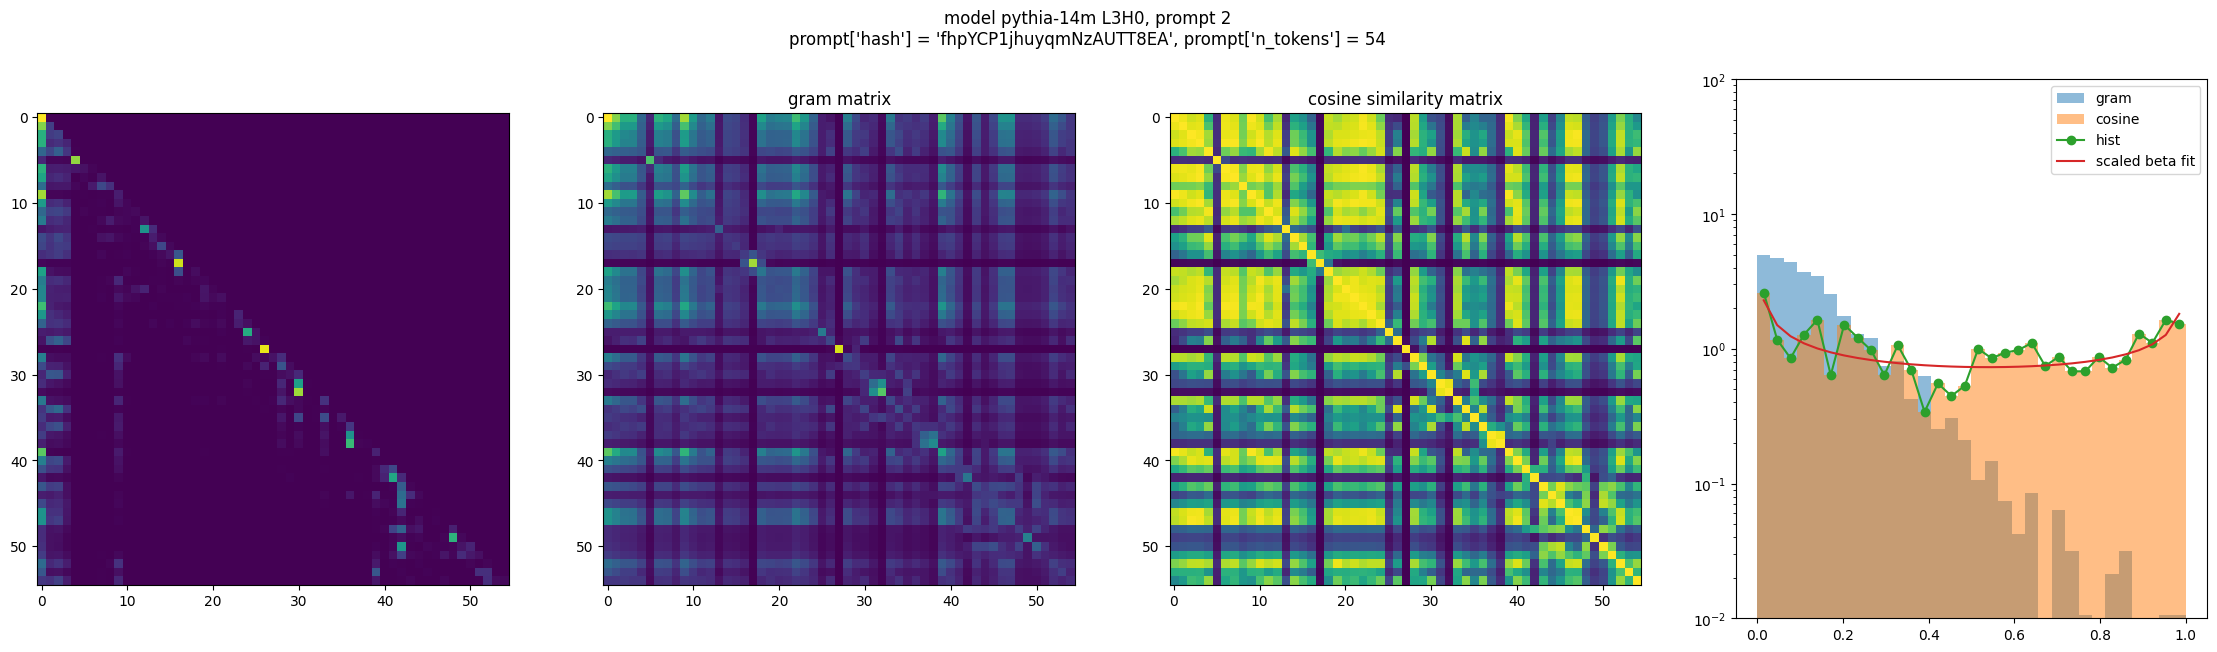

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (2, 4, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.19 σ=0.28 x̃=0.07 R=[0.00,1.00] ℙ=|█▆▅▄▄▄▅| shape=3025 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=2.01 x̃=0.48 R=[0.15,11.58] ℙ=|█▁▁   ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.37356350794431376, 0.8094837533635515, -0.04953001075790252, 1.1751736866869291)


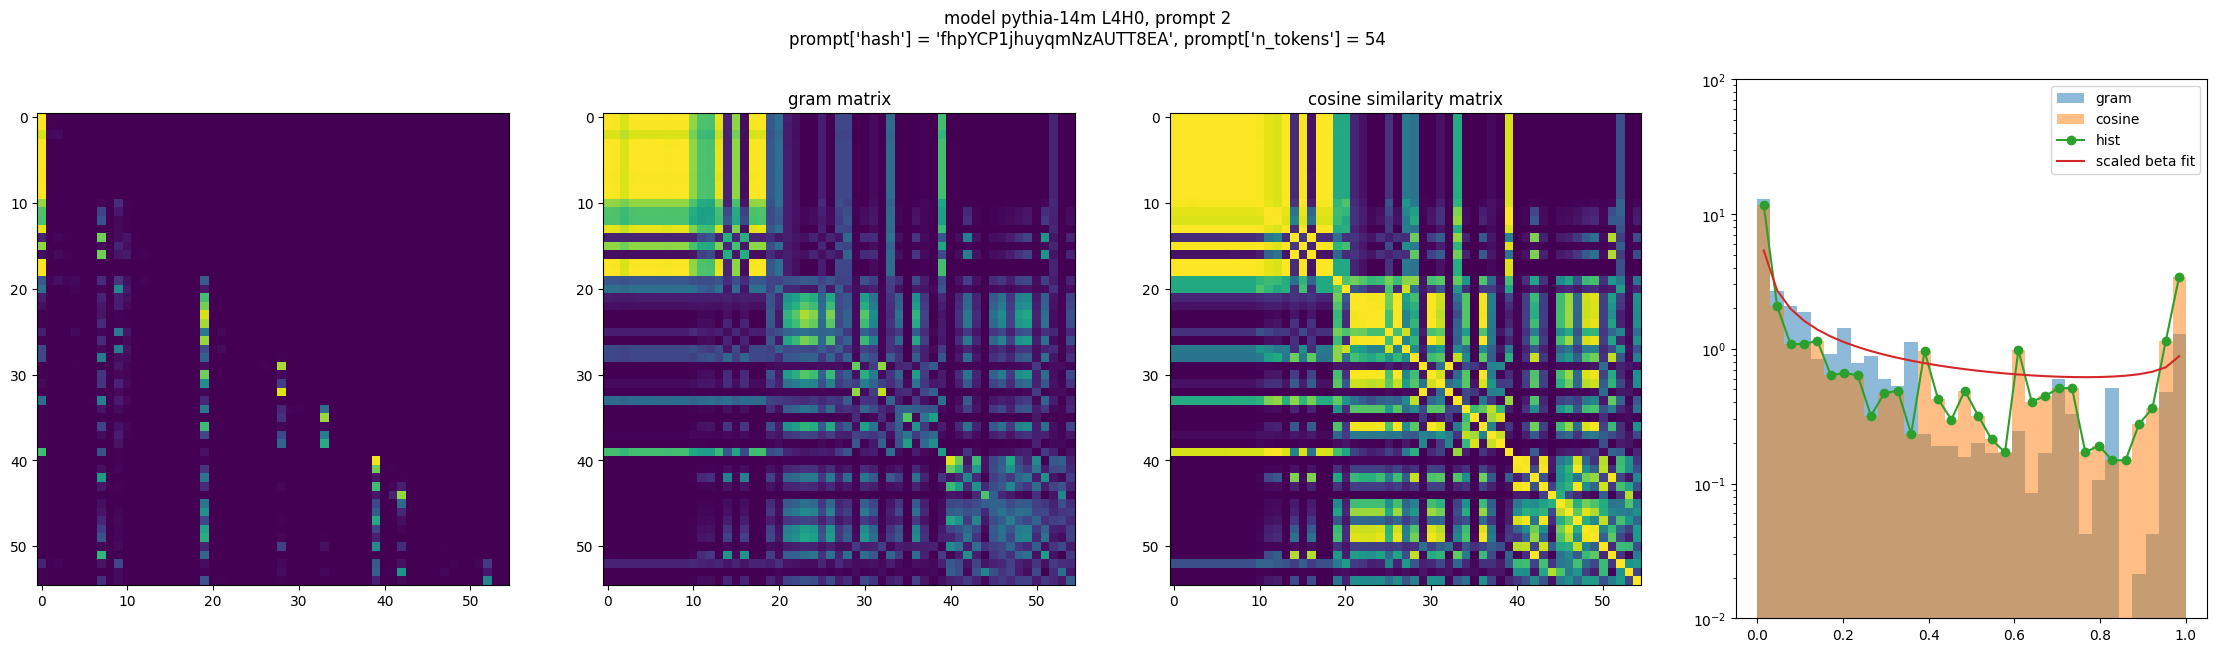

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (2, 5, 0)
[ <ipykernel>:56 -> fig_gram ] mat_gram.flatten(): μ=0.11 σ=0.23 x̃=0.00 R=[0.00,1.00] ℙ=|█▅▅▄▄▃▄| shape=3025 dtype=float32
[ <ipykernel>:57 -> fig_gram ] x_hist: μ=1.00 σ=3.53 x̃=0.32 R=[0.04,20.58] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:68 -> fig_gram ] (alpha_est, beta_est, loc, scale) = (0.09702962439045319, 0.4439102840265778, -0.003999131286966301, 1.0210263665164134)


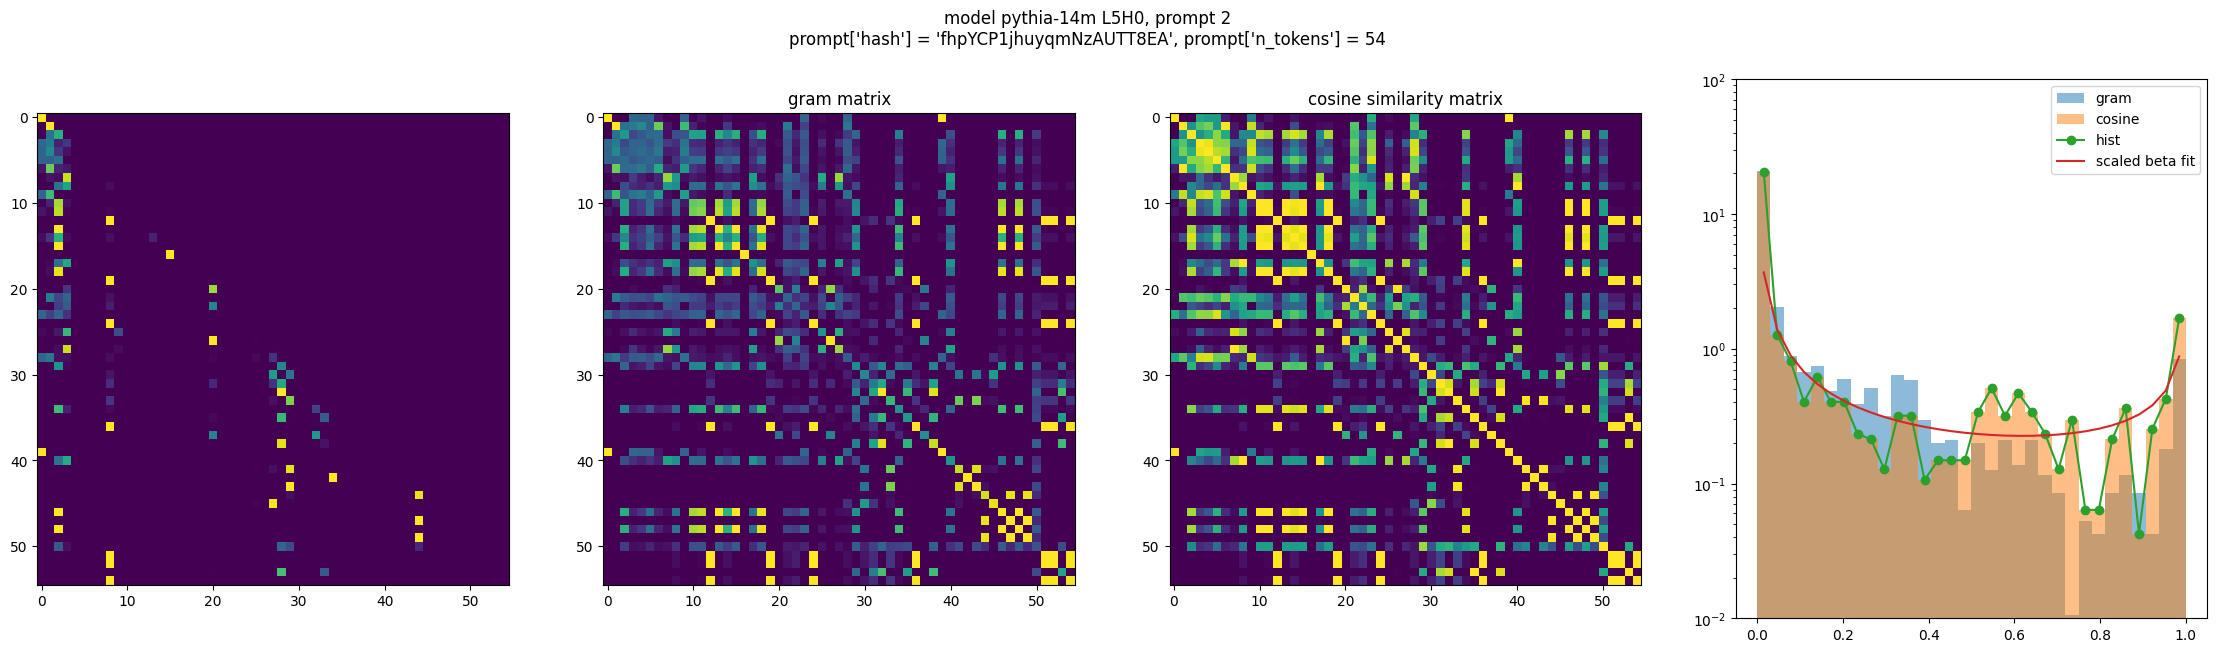

In [9]:
import scipy.stats as stats
from scipy.optimize import curve_fit

from attention_motifs.bins import Bins

def cosine_similarity_matrix(
    X: Float[np.ndarray, "n n"],
    col: bool = False,
    eps: float = 1e-10
) -> np.ndarray:
    # If col==True, treat columns as vectors (i.e., work on the transposed matrix)
    X_: Float[np.ndarray, "n n"] = X.T if col else X
    
    # Compute the dot product matrix for the chosen vectors (rows of X_)
    dot_product: Float[np.ndarray, "n n"] = X_ @ X_.T

    # Compute the norm of each vector (row) in X_
    norms: Float[np.ndarray, "n"] = np.linalg.norm(X_, axis=1)
    
    # Compute the cosine similarity matrix, adding eps to avoid division by zero
    similarity_matrix: np.ndarray = dot_product / ((norms[:, None] * norms[None, :]) + eps)
    return similarity_matrix

def scaled_beta(x: np.ndarray, alpha: float, beta: float, scale: float) -> np.ndarray:
	"""Scaled beta distribution."""
	return stats.beta.pdf(x, alpha, beta) * scale

def fig_gram(A: np.ndarray, axs: list[plt.Axes], p_idx: int, lyr: int, head: int):

	n_ctx: int = A.shape[0]
	ax_raw, ax_gram, ax_cossim, ax_hist = axs
      
	ax_raw.imshow(A)

	mat_gram = A @ A.T
	ax_gram.imshow(mat_gram)
	ax_gram.set_title("gram matrix")
	mat_cos = cosine_similarity_matrix(A)
	ax_cossim.imshow(mat_cos)
	ax_cossim.set_title("cosine similarity matrix")

	bins: Bins = Bins(scale="lin")
	ax_hist.set_yscale("log")
	ax_hist.set_xscale("linear")
	x_hist, _ = np.histogram(
		# mat_gram.flatten(),
		mat_cos.flatten(),
		bins=bins.edges,
		density=True,
	)
	# x_hist = x_hist / n_ctx
	ax_hist.hist(mat_gram.flatten(), bins=bins.edges, density=True, alpha=0.5, label="gram")
	ax_hist.hist(mat_cos.flatten(), bins=bins.edges, density=True, alpha=0.5, label="cosine")
	ax_hist.plot(bins.centers, x_hist, "-o", label="hist")

	dbg_tensor(mat_gram.flatten())
	dbg_tensor(x_hist)
	alpha_est, beta_est, loc, scale = stats.beta.fit(mat_cos, method="MM")
	# popt, pcov = curve_fit(
	# 	scaled_beta,
	# 	bins.centers,
	# 	x_hist,
	# 	p0=(1.0, 1.0, 1.0),
	# 	maxfev=999999,
	# )
	# print(f"popt: {popt}")
	# print(f"pcov: {pcov}")
	dbg((alpha_est, beta_est, loc, scale))
	ax_hist.plot(
		bins.centers,
		scaled_beta(bins.centers, alpha_est, beta_est, scale),
		label="scaled beta fit",
	)
	ax_hist.set_ylim(1e-2, 1e2)

	ax_hist.legend()
	# ax_gram_col.imshow(A @ A_col0.T)
	# ax_gram_col.set_title("gram matrix col0")
	# ax_cossim_col.imshow(cosine_similarity_matrix(A_col0))
	# ax_cossim_col.set_title("cosine similarity matrix col0")


plot_figs(
	n_figures=4,
	model_cfg=MODEL_CFG,
	prompt_dicts=PROMPTS,
	activations=ACTIVATIONS,
	# figure_func=fig,
	figure_func=fig_gram,
	prompts=[0, 1, 2],
	layers=None,
	heads=[0],
)

plt.show()